In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
import flexiznam as flz
import sys
from cottage_analysis.preprocessing import synchronisation
from cottage_analysis.analysis.gratings import generate_trials_df
from cottage_analysis.analysis.gratings import analyze_grating_responses

In [5]:
def find_recordings(base_dir="/Volumes/lab-znamenskiyp/home/shared/projects/"):
    base_path = Path(base_dir)
    print(f"Base path set to: {base_path}")

    project_name = "toksozi_in-vivo-BRISC"
    mouse_name = "BRAC10754.8c"
    session_name = "S20251028"
    protocol = "SFTF"

    session_path = base_path / project_name / mouse_name / session_name
    
    if not session_path.exists():
        print(f"\n[ERROR] The path does not exist:\n{session_path}")
        print("Please check your spelling and try again.")
        return None, None, None

    print(f"\nLooking for recordings in: {session_path}")
    recordings = sorted([p for p in session_path.iterdir() if p.is_dir() and p.name.startswith("R")])
    
    if not recordings:
        print("[WARNING] No recordings found starting with 'R' in this session folder.")
        return None, None, None
    
    print(f"Found {len(recordings)} recording(s):")
    for rec in recordings:
        print(f" - {rec.name}")
    flexiznam_session_id = f"{mouse_name}_{session_name}"
    
    return project_name, flexiznam_session_id, protocol


In [6]:
def run_analysis(project_name, session_id, protocol):
    if not project_name or not session_id:
        print("Invalid project or session ID. Aborting analysis.")
        return

    print(f"\n>>> Starting {protocol} analysis for {session_id}...")
    
    try:
        trials_df, dff_mean_all = analyze_grating_responses(
            project=project_name,
            session=session_id,
            protocol_base=protocol
        )
        
        print("\n>>> Analysis Complete!")
        print(f"Result: Trials DataFrame with shape {trials_df.shape}")

        return trials_df, dff_mean_all

    except Exception as e:
        print(f"\n[ERROR] Analysis failed: {e}")
        import traceback
        traceback.print_exc()
        return None, None

In [7]:
if __name__ == "__main__":
    # Find the recordings
    proj, sess_id, proto = find_recordings()
    
    # If valid recordings were found, run the analysis
    if proj and sess_id:
        trials_df, dff_mean = run_analysis(proj, sess_id, proto)
    
    print("\nFirst 5 rows of your data:")
    display(trials_df.head())

    

Base path set to: /Volumes/lab-znamenskiyp/home/shared/projects

Looking for recordings in: /Volumes/lab-znamenskiyp/home/shared/projects/toksozi_in-vivo-BRISC/BRAC10754.8c/S20251028
Found 1 recording(s):
 - R094333_SFTF

>>> Starting SFTF analysis for BRAC10754.8c_S20251028...
Loading existing monitor frames...
Removing frames in wrong order of frame indices.
Removed 12 frames including:
0 negative diffs.
12 duplicates.
Removed 0 frames including:
0 negative diffs.
0 duplicates.
2 frames are not 0.0334 s
ImagingFrames in video: 206024
ImagingFrame triggers: 206027
Triggers - Frames: 3
FRAME NUMBER NOT CORRECT likely due to incomplete imaging volume at the end of the stack or bonsai crash.

>>> Analysis Complete!
Result: Trials DataFrame with shape (1709, 23)

First 5 rows of your data:


,imaging_harptime,imaging_frame,imaging_volume,imaging_harptime_end,monitor_frame,monitor_harptime,mouse_z,eye_z,stimulus_harptime,Frameindex,...,TemporalFrequency,Angle,Phase,mouse_z_harptime,mouse_z_harp,dffs,stim_start,stim_end,dff_stim,irecording
0,1.034472e+07,1064,152,1.034472e+07,5294,1.034472e+07,356.32,356.32,1.034472e+07,5263.0,...,1.0,315.0,0.0,1.034472e+07,5.471249,"[[-0.23258994673906275, -0.18253380045638334, ...",154,171.0,"[[0.45879047306594456, 0.7543742300926913, 0.2...",BRAC10754.8c_S20251028_R094333_SFTF
1,1.034472e+07,1183,169,1.034472e+07,5847,1.034472e+07,366.86,366.86,1.034472e+07,5824.0,...,1.0,90.0,0.0,1.034472e+07,5.627869,"[[0.19925032081321187, -0.45551256528969947, -...",171,188.0,"[[0.7203394544269534, 0.23473948837401354, -0....",BRAC10754.8c_S20251028_R094333_SFTF
2,1.034472e+07,1302,186,1.034472e+07,6407,1.034472e+07,404.17,404.17,1.034472e+07,6384.0,...,2.0,90.0,0.0,1.034472e+07,6.210628,"[[-0.3757993264900213, 0.6700018120798173, -0....",188,205.0,"[[-1.1126181459834852, 0.015955246171212644, 0...",BRAC10754.8c_S20251028_R094333_SFTF
3,1.034473e+07,1421,203,1.034473e+07,6963,1.034473e+07,447.36,447.36,1.034473e+07,6944.0,...,8.0,90.0,0.0,1.034473e+07,6.871620,"[[1.4338027810094958, 0.11640877368194778, 0.2...",205,222.0,"[[0.5486756262718488, -0.13005574228685207, 1....",BRAC10754.8c_S20251028_R094333_SFTF
4,1.034473e+07,1540,220,1.034473e+07,7519,1.034473e+07,471.60,471.60,1.034473e+07,7504.0,...,1.0,90.0,0.0,1.034473e+07,7.234560,"[[1.0727640744027727, 0.17271503492376822, 0.4...",222,239.0,"[[-0.5555062884556562, 0.016338675633810206, 0...",BRAC10754.8c_S20251028_R094333_SFTF


In [8]:
import pandas as pd
import numpy as np
from cottage_analysis.analysis.fit_gaussian_blob import fit_sftf_tuning

# 1. Unpack the 'dff_stim' column
# This calculates the mean response for every neuron in every trial
print("Formatting data for fitting...")
# Stack turns the list of arrays into a big matrix (Trials x Neurons)
response_matrix = np.stack(trials_df['dff_stim'].apply(lambda x: np.mean(x, axis=0)).values)

# 2. Create a DataFrame with integer column names (0, 1, 2...)
# These integers effectively become the "ROI IDs"
responses_df = pd.DataFrame(
    response_matrix, 
    columns=np.arange(response_matrix.shape[1]), 
    index=trials_df.index
)

# 3. Combine with the stimulus information
# We keep the original stimulus columns and add the new neuron columns
trials_df_formatted = pd.concat(
    [trials_df[['SpatialFrequency', 'TemporalFrequency', 'Angle']], responses_df], 
    axis=1
)

print(f"Data formatted! New shape: {trials_df_formatted.shape}")
print(f" (Should be approx {len(trials_df)} rows x {response_matrix.shape[1] + 3} columns)")

# 4. Now run the fit on the formatted data
print("\nFitting Gaussian blobs... (This may take 1-5 minutes)")
neurons_df = fit_sftf_tuning(trials_df_formatted)

print("\nFitting complete!")
print(f"Neurons DataFrame shape: {neurons_df.shape}")
display(neurons_df.head())

Formatting data for fitting...
Data formatted! New shape: (1709, 1779)
 (Should be approx 1709 rows x 1779 columns)

Fitting Gaussian blobs... (This may take 1-5 minutes)


  0%|          | 4/1776 [00:00<04:47,  6.16it/s]/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:342: RuntimeWarning: overflow encountered in exp
  resp = np.exp(kappa * np.cos(alpha - alpha0)) + (1 - dsi) * np.exp(
/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:345: RuntimeWarning: overflow encountered in exp
  peak_resp = np.exp(kappa) + (1 - dsi) * np.exp(-kappa)
/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:346: RuntimeWarning: invalid value encountered in divide
  return resp / peak_resp
  0%|          | 6/1776 [00:01<07:46,  3.79it/s]/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:99: RuntimeWarning: overflow encountered in exp
  sigma_y_sq = np.exp(log_sigma_y2) + min_sigma
/Users/toksozi/code/cottage_analysis/cottage_analysis/analysis/fit_gaussian_blob.py:99: RuntimeWarning: overflow encountered in exp
  sigma_y_sq = np.exp(log_sigma_


Fitting complete!
Neurons DataFrame shape: (1776, 11)


,log_amplitude,sf0,tf0,log_sigma_x2,log_sigma_y2,theta,offset,alpha0,log_kappa,dsi,rsq
0,-2.656632,-0.139434,-0.152813,2.288654,-374.660321,6.393087e-31,0.257368,5.229682,1.205947,1.642538e-20,0.008726
1,-2.861904,-1.304386,-1.333599,-3.032747,0.998603,4.922127e-01,0.198744,4.546612,0.724998,3.450962e-10,0.009034
2,-3.013748,-2.199972,0.225890,29.140731,-22.565047,1.164082e+00,0.272522,2.227747,0.631397,2.666027e-01,0.007788
3,0.205382,-0.139436,0.431256,-15.234943,-16.124493,1.492187e+00,0.357840,4.117434,0.762044,8.012135e-01,0.007636
4,0.016871,-5.427015,-0.293023,-15.754841,15.134750,9.899093e-01,0.494355,4.370255,3.374823,1.000000e+00,0.003794


Plotting Raw Data for ROI 144 (R2: 0.67)


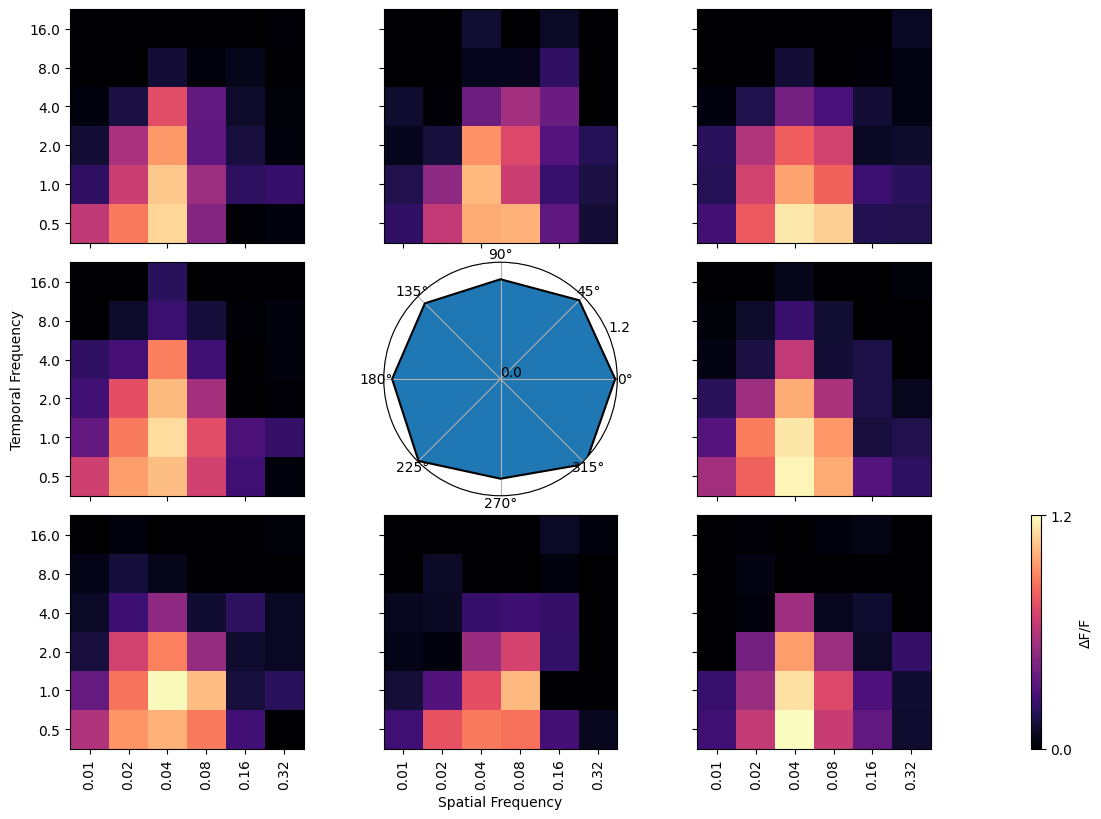

In [9]:
from cottage_analysis.plotting import grating_plots
import matplotlib.pyplot as plt

# 1. Pick a good neuron (e.g., highest R-squared)
best_roi = neurons_df['rsq'].idxmax()
print(f"Plotting Raw Data for ROI {best_roi} (R2: {neurons_df.loc[best_roi, 'rsq']:.2f})")

# 2. Setup the figure
plt.figure(figsize=(10, 8))

# 3. Plot
# Note: We use 'trials_df_formatted' here!
grating_plots.plot_sftf_tuning(
    trials_df=trials_df_formatted, 
    roi=best_roi,
    plot_grid=True  # Plots separate heatmaps for each direction
)

plt.show()

Generating full report for ROI 144...


/Users/toksozi/code/cottage_analysis/cottage_analysis/plotting/grating_plots.py:311: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.005)


<Figure size 1500x1000 with 0 Axes>

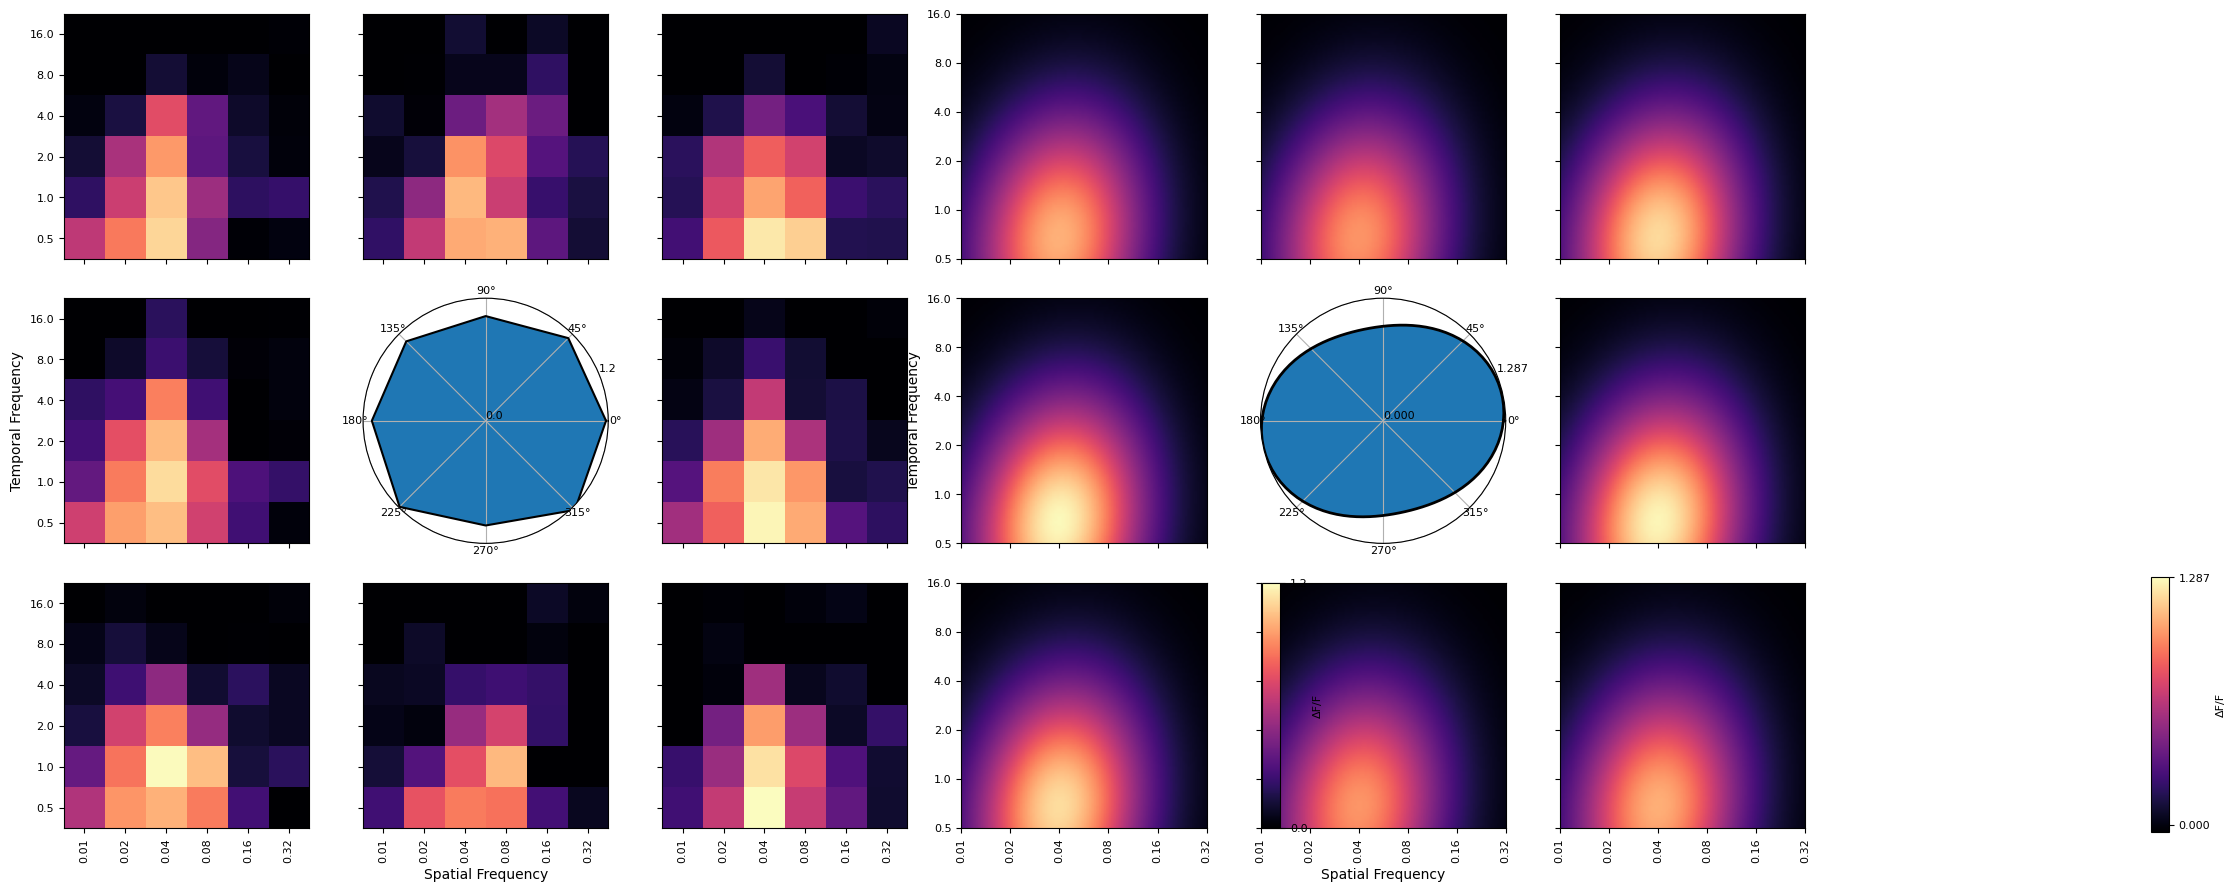

In [10]:
# Create a larger figure for the comparison
plt.figure(figsize=(15, 10))

print(f"Generating full report for ROI {best_roi}...")

grating_plots.basic_vis_SFTF_roi(
    neurons_df=neurons_df,
    trials_df_depth=None,          # No depth data
    trials_df_sftf=trials_df_formatted, # Use the formatted dataframe
    roi=best_roi,
    add_depth=False,
    fontsize_dict={'title': 12, 'label': 10, 'tick': 8}
)

plt.show()